In [59]:
import numpy as np

In [98]:
# Task1
def loss(w, x, y):
    M = np.dot(x, w) * y
    return np.log2(1 + np.exp(-M))

def df(w, x, y):
    M = np.dot(w, x) * y
    return -(np.exp(-M) * x.T * y) / ((1 + np.exp(-M)) * np.log(2))

data_x = [(3.0, 4.9), (2.7, 3.9), (3.0, 5.5), (2.6, 4.0), (2.9, 4.3), (3.1, 5.1), (2.2, 4.5), (2.3, 3.3), (2.7, 5.1), (3.3, 5.7), (2.8, 5.1), (2.8, 4.9), (2.5, 4.5), (2.8, 4.7), (3.2, 4.7), (3.2, 5.7), (2.8, 6.1), (3.6, 6.1), (2.8, 4.8), (2.9, 4.5), (3.1, 4.9), (2.3, 4.4), (3.3, 6.0), (2.6, 5.6), (3.0, 4.4), (2.9, 4.7), (2.8, 4.0), (2.5, 5.8), (2.4, 3.3), (2.8, 6.7), (3.0, 5.1), (2.3, 4.0), (3.1, 5.5), (2.8, 4.8), (2.7, 5.1), (2.5, 4.0), (3.1, 4.4), (3.8, 6.7), (3.1, 5.6), (3.1, 4.7), (3.0, 5.8), (3.0, 5.2), (3.0, 4.5), (2.7, 4.9), (3.0, 6.6), (2.9, 4.6), (3.0, 4.6), (2.6, 3.5), (2.7, 5.1), (2.5, 5.0), (2.0, 3.5), (3.2, 5.9), (2.5, 5.0), (3.4, 5.6), (3.4, 4.5), (3.2, 5.3), (2.2, 4.0), (2.2, 5.0), (3.3, 4.7), (2.7, 4.1), (2.4, 3.7), (3.0, 4.2), (3.2, 6.0), (3.0, 4.2), (3.0, 4.5), (2.7, 4.2), (2.5, 3.0), (2.8, 4.6), (2.9, 4.2), (3.1, 5.4), (2.5, 4.9), (3.2, 5.1), (2.8, 4.5), (2.8, 5.6), (3.4, 5.4), (2.7, 3.9), (3.0, 6.1), (3.0, 5.8), (3.0, 4.1), (2.5, 3.9), (2.4, 3.8), (2.6, 4.4), (2.9, 3.6), (3.3, 5.7), (2.9, 5.6), (3.0, 5.2), (3.0, 4.8), (2.7, 5.3), (2.8, 4.1), (2.8, 5.6), (3.2, 4.5), (3.0, 5.9), (2.9, 4.3), (2.6, 6.9), (2.8, 5.1), (2.9, 6.3), (3.2, 4.8), (3.0, 5.5), (3.0, 5.0), (3.8, 6.4)]
data_y = [1, -1, 1, -1, -1, 1, -1, -1, -1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, -1, -1, -1, 1, 1, -1, -1, -1, 1, -1, 1, 1, -1, 1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, 1, -1, -1, -1, 1, 1, -1, 1, 1, 1, -1, 1, -1, 1, -1, -1, -1, -1, 1, -1, -1, -1, -1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, 1, -1, 1, -1, 1, 1, 1, -1, 1, -1, 1]

x_train = np.array([[1, x[0], x[1]] for x in data_x]) # (N, 3)
y_train = np.array(data_y)

n_train = len(x_train)
w = np.array([0.0, 0.0, 0.0]) # (3,) 
nt = np.array([0.5, 0.01, 0.01])
lm = 0.01
N = 1000

Qe = np.mean((np.dot(x_train, w) * y_train) < 0)
np.random.seed(0)

In [99]:
print(f'Qe = {Qe:.4f}')

Qe = 0.0000


In [105]:
for _ in range(N):
    k = np.random.randint(0, n_train-1)
    x_k = x_train[k]
    y_k = y_train[k]
    Lk = loss(w, x_k, y_k)
    w = w - nt * df(w, x_k, y_k)
    Qe = lm*Lk + (1-lm)*Qe
print(w.shape)
print(df(w, x_k, y_k).shape)
Q = np.mean((np.dot(x_train, w) * y_train) < 0)

(3,)
(3,)


In [101]:
print(f'w = {w}')
print(f'Qe = {Qe:.4f}')
print(f'Q = {Q:.4f}')


w = [-8.15553401 -0.15656274  1.78240069]
Qe = 0.5639
Q = 0.0700


In [102]:
data_y == 1

False

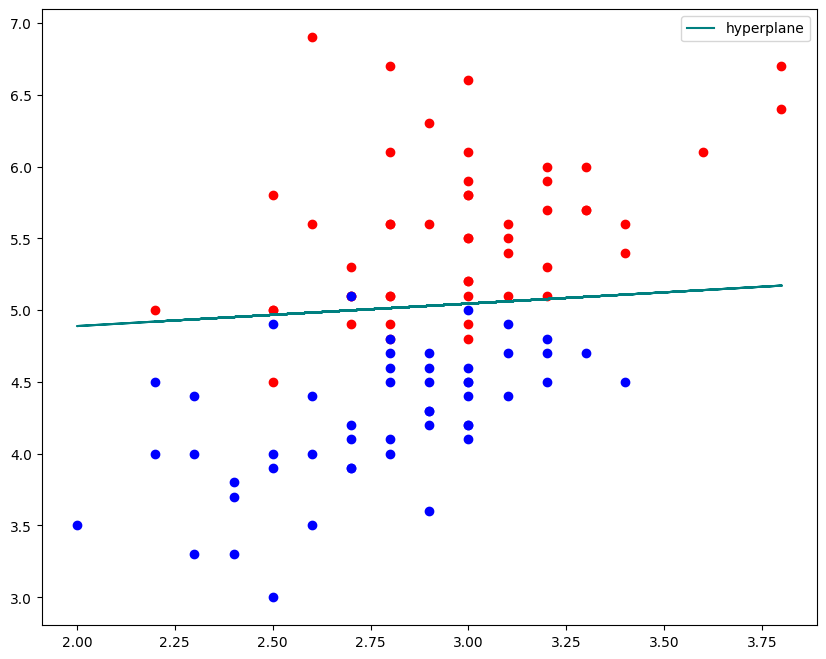

In [103]:
import matplotlib.pyplot as plt
data_x = np.array(data_x)
data_y = np.array(data_y)
x_0 = data_x[data_y == 1]
x_1 = data_x[data_y == -1]
line_x = data_x[:, 0]
line_y = -w[1]*data_x[:, 0] - w[0] / w[2]
plt.figure(figsize=(10, 8))
plt.scatter(x_0[:, 0], x_0[:, 1], c='red')
plt.scatter(x_1[:, 0], x_1[:, 1], c='blue')
plt.plot(line_x, line_y, c='teal', label = 'hyperplane')
plt.legend()
plt.show()

In [256]:
# Task2
def loss(w, x, y):
    M = np.dot(x, w) * y
    return np.exp(-M)

def df(w, x, y):
    M = np.dot(x, w) * y
    return -np.exp(-M) * x.T * y

data_x = [(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)]
data_y = [-1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1]

x_train = np.array([[1, x[0], x[1]] for x in data_x])
y_train = np.array(data_y)

n_train = len(x_train)  # размер обучающей выборки
w = np.array([0.0, 0.0, 0.0])  # начальные весовые коэффициенты
nt = np.array([0.5, 0.01, 0.01])  # шаг обучения для каждого параметра w0, w1, w2
lm = 0.01  # значение параметра лямбда для вычисления скользящего экспоненциального среднего
N = 500  # число итераций алгоритма SGD
batch_size = 10 # размер мини-батча (величина K = 10)
Qe = np.mean(loss(w, x_train, y_train))
Qe_ls = [Qe]
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел]
for i in range(N):
    k = np.random.randint(0, n_train-batch_size-1)
    x_batch = x_train[k:k+batch_size]
    y_batch = y_train[k:k+batch_size]
    dw = np.mean(df(w, x_batch, y_batch), axis=1)
    w = w - dw * nt
    Lk = np.mean(loss(w, x_batch, y_batch), axis=0)
    Qe = lm * Lk + (1-lm)*Qe
    Qe_ls.append(Qe)
Q = np.mean((np.dot(x_train, w) * y_train)>0)

In [267]:
import numpy as np
# Task2
def loss(w, x, y):
    M = np.dot(x, w) * y
    return np.exp(-M)

def df(w, x, y):
    M = np.dot(x, w) * y
    return -np.exp(-M) * x.T * y

data_x = [(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)]
data_y = [-1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1]

x_train = np.array([[1, x[0], x[1]] for x in data_x])
y_train = np.array(data_y)

n_train = len(x_train)  # размер обучающей выборки
w = np.array([0.0, 0.0, 0.0])  # начальные весовые коэффициенты
nt = np.array([0.5, 0.01, 0.01])  # шаг обучения для каждого параметра w0, w1, w2
lm = 0.01  # значение параметра лямбда для вычисления скользящего экспоненциального среднего
N = 500  # число итераций алгоритма SGD
batch_size = 10 # размер мини-батча (величина K = 10)
Qe = np.mean(loss(w, x_train, y_train))
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел]
for i in range(N):
    k = np.random.randint(0, n_train-batch_size-1)
    x_batch = x_train[k:k+batch_size]
    y_batch = y_train[k:k+batch_size]
    dw = np.mean(df(w, x_batch, y_batch), axis=1)
    Lk = np.mean(loss(w, x_batch, y_batch), axis=0)
    Qe = lm * Lk + (1-lm)*Qe
    w = w - dw * nt
    Lk = np.mean(loss(w, x_batch, y_batch), axis=0)
    
Q = np.mean((np.dot(x_train, w) * y_train)<0)

In [268]:
print(f'w = {w}')
print(f'Qe = {Qe}')
print(F'Q = {Q}')

w = [-3.99368023  0.34850649  1.07879392]
Qe = 0.7092738058526213
Q = 0.07


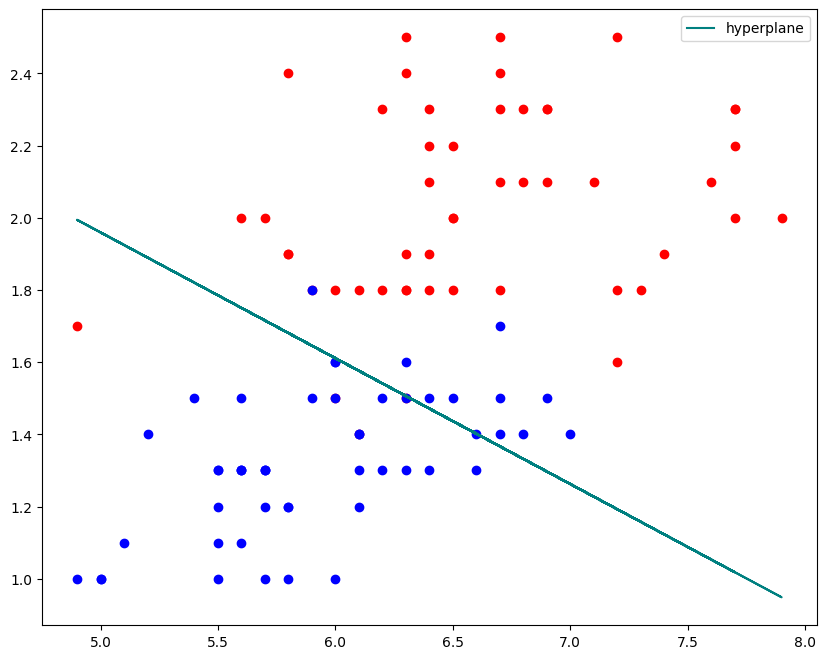

In [248]:
import matplotlib.pyplot as plt
data_x = np.array(data_x)
data_y = np.array(data_y)
x_0 = data_x[data_y == 1]
x_1 = data_x[data_y == -1]
line_x = data_x[:, 0]
line_y = -w[1]*data_x[:, 0] - w[0] / w[2]
plt.figure(figsize=(10, 8))
plt.scatter(x_0[:, 0], x_0[:, 1], c='red')
plt.scatter(x_1[:, 0], x_1[:, 1], c='blue')
plt.plot(line_x, line_y, c='teal', label = 'hyperplane')
plt.legend()
plt.show()

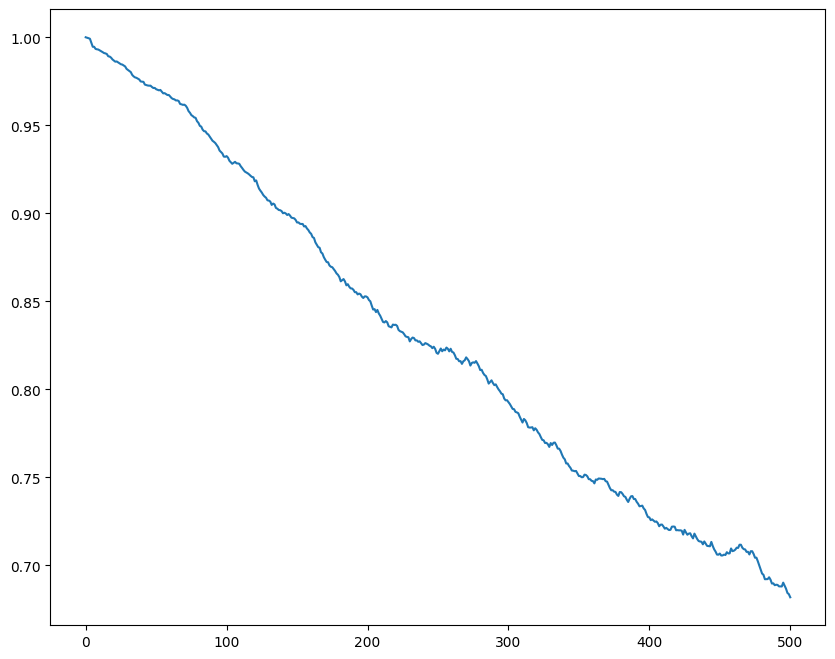

In [249]:
plt.figure(figsize=(10, 8))
plt.plot(np.arange(len(Qe_ls)), Qe_ls)
plt.show()